## ======================================================================
## 🧠 Hopify SaaS: Annual Revenue per User (ARPU) by Segment Time-Series
## ======================================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# ================================
# 📁 Set Base Path to Project Root
# ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ==================================================
## 📥 Load Data
## ==================================================

In [2]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "02_project_revenue_profit_analysis",
    "05_hopify_monthly_arpu_act_v_target_seg.csv"
)

df = pd.read_csv(file_path)

## ================================
## 🧼 Clean & Prepare Columns
## ================================


In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("%", "percent")
    .str.replace("-", "_")
    .str.lower()
)

df['month'] = pd.to_datetime(df['month'], errors='coerce')
df['quarter'] = df['month'].dt.to_period('Q').astype(str)

# Sort segments and quarters (most recent first)
segment_order = ["Enterprise", "Mid-Market", "SMB"]
df['segment'] = pd.Categorical(df['segment'], categories=segment_order, ordered=True)

quarter_order = sorted(df['quarter'].unique(), reverse=True)
df['quarter'] = pd.Categorical(df['quarter'], categories=quarter_order, ordered=True)
df = df.sort_values(['segment', 'quarter'], ascending=[True, False])


## ==================================================
## ARPU by Segment Time-Series Plot
## ==================================================

/Users/jade.herman/Documents/00_github/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/jade.herman/Documents/00_github/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/jade.herman/Documents/00_github/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


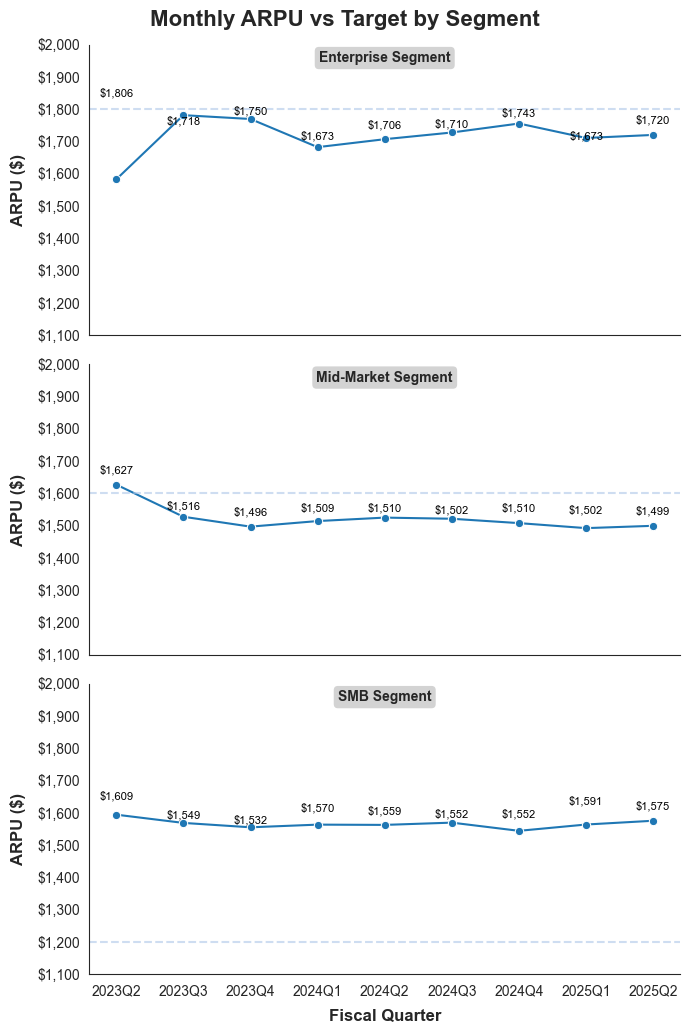

In [4]:
# ================================
# 🎨 Define Color Palette
# ================================

colors = {
    "arpu": "#1f77b4",      # Blue
    "target": "#aec7e8"     # Light Blue
}

# ================================
# 📊 Plot ARPU Trends by Segment
# ================================

sns.set_style("white")
g = sns.FacetGrid(df, col='segment', col_wrap=1, height=3.5, aspect=2, sharey=True)
g.map_dataframe(sns.lineplot, x='quarter', y='arpu', marker='o', color=colors['arpu'], ci=None)

for ax, segment in zip(g.axes.flat, segment_order):
    seg_df = df[df['segment'] == segment]
    if not seg_df.empty:
        target_val = seg_df['arpu_target'].iloc[0]
        ax.axhline(y=target_val, linestyle='--', color=colors['target'], linewidth=1.5, alpha=0.6)

        ax.text(
            0.5, 0.93, f"{segment} Segment",
            transform=ax.transAxes,
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgrey', edgecolor='none')
        )

        for _, row in seg_df.drop_duplicates(subset=["quarter"]).iterrows():
            ax.annotate(
                f"${row['arpu']:,.0f}",
                xy=(row['quarter'], row['arpu']),
                xytext=(0, 8),
                textcoords='offset points',
                ha='center',
                fontsize=8,
                color='black'
            )

        ax.set_ylim(1100, 2000)
        ax.grid(False)

    ax.set_title("")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.tick_params(axis='x', labelrotation=0)
    ax.invert_xaxis()

# Axis labels
g.set_axis_labels("Fiscal Quarter", "ARPU ($)")
for ax in g.axes.flat:
    ax.set_xlabel("Fiscal Quarter", fontsize=12, fontweight='bold', labelpad=8)
    ax.set_ylabel("ARPU ($)", fontsize=12, fontweight='bold', labelpad=8)

# Final layout
g.fig.subplots_adjust(top=0.88, bottom=0.08)
g.fig.suptitle("Monthly ARPU vs Target by Segment", fontsize=16, fontweight='bold')
plt.tight_layout()


## ================================
## 💾 Save & Show
## ================================

In [5]:
output_path = os.path.join(BASE_PATH, "05_visuals", "hopify_arpu_vs_target_seg.png")
plt.savefig(output_path, dpi=300)
plt.show()


<Figure size 640x480 with 0 Axes>